In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("PJME_hourly.csv")
df.head()


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [3]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (145366, 2)

Column Names:
Index(['Datetime', 'PJME_MW'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB

Missing Values:
Datetime    0
PJME_MW     0
dtype: int64


In [4]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

df = df.sort_values("Datetime").reset_index(drop=True)

df.head()

,Datetime,PJME_MW
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0


In [5]:
print("Start Date:", df["Datetime"].min())
print("End Date:", df["Datetime"].max())

print("\nDemand Statistics:")
print(df["PJME_MW"].describe())

print("\nDuplicate Rows:", df.duplicated().sum())

Start Date: 2002-01-01 01:00:00
End Date: 2018-08-03 00:00:00

Demand Statistics:
count    145366.000000
mean      32080.222831
std        6464.012166
min       14544.000000
25%       27573.000000
50%       31421.000000
75%       35650.000000
max       62009.000000
Name: PJME_MW, dtype: float64

Duplicate Rows: 0


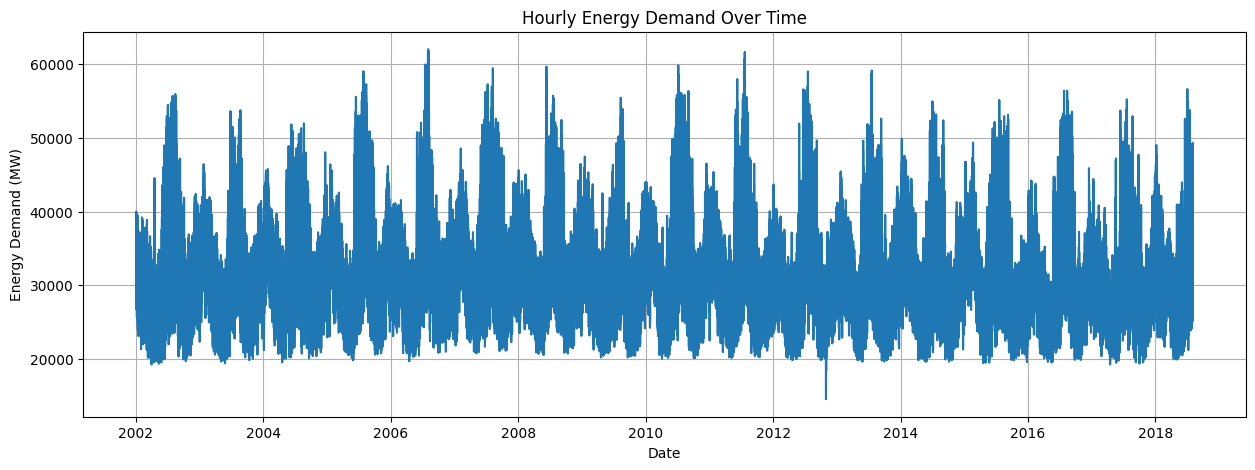

In [6]:
plt.figure(figsize=(15, 5))

plt.plot(df["Datetime"], df["PJME_MW"])

plt.title("Hourly Energy Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Energy Demand (MW)")
plt.grid(True)
plt.show()

In [7]:
df["Hour"] = df["Datetime"].dt.hour
df["Day"] = df["Datetime"].dt.day
df["DayOfWeek"] = df["Datetime"].dt.dayofweek
df["Month"] = df["Datetime"].dt.month
df["Year"] = df["Datetime"].dt.year
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

df.head()

,Datetime,PJME_MW,Hour,Day,DayOfWeek,Month,Year,IsWeekend
0,2002-01-01 01:00:00,30393.0,1,1,1,1,2002,0
1,2002-01-01 02:00:00,29265.0,2,1,1,1,2002,0
2,2002-01-01 03:00:00,28357.0,3,1,1,1,2002,0
3,2002-01-01 04:00:00,27899.0,4,1,1,1,2002,0
4,2002-01-01 05:00:00,28057.0,5,1,1,1,2002,0


In [8]:
df["Lag_1"] = df["PJME_MW"].shift(1)
df["Lag_24"] = df["PJME_MW"].shift(24)
df["Lag_168"] = df["PJME_MW"].shift(168)

df.head(10)

,Datetime,PJME_MW,Hour,Day,DayOfWeek,Month,Year,IsWeekend,Lag_1,Lag_24,Lag_168
0,2002-01-01 01:00:00,30393.0,1,1,1,1,2002,0,NaN,NaN,NaN
1,2002-01-01 02:00:00,29265.0,2,1,1,1,2002,0,30393.0,NaN,NaN
2,2002-01-01 03:00:00,28357.0,3,1,1,1,2002,0,29265.0,NaN,NaN
3,2002-01-01 04:00:00,27899.0,4,1,1,1,2002,0,28357.0,NaN,NaN
4,2002-01-01 05:00:00,28057.0,5,1,1,1,2002,0,27899.0,NaN,NaN
5,2002-01-01 06:00:00,28654.0,6,1,1,1,2002,0,28057.0,NaN,NaN
6,2002-01-01 07:00:00,29308.0,7,1,1,1,2002,0,28654.0,NaN,NaN
7,2002-01-01 08:00:00,29595.0,8,1,1,1,2002,0,29308.0,NaN,NaN
8,2002-01-01 09:00:00,29943.0,9,1,1,1,2002,0,29595.0,NaN,NaN
9,2002-01-01 10:00:00,30692.0,10,1,1,1,2002,0,29943.0,NaN,NaN


In [9]:
df["Rolling_Mean_24"] = df["PJME_MW"].shift(1).rolling(24).mean()
df["Rolling_Mean_168"] = df["PJME_MW"].shift(1).rolling(168).mean()

df.head(10)

,Datetime,PJME_MW,Hour,Day,DayOfWeek,Month,Year,IsWeekend,Lag_1,Lag_24,Lag_168,Rolling_Mean_24,Rolling_Mean_168
0,2002-01-01 01:00:00,30393.0,1,1,1,1,2002,0,NaN,NaN,NaN,NaN,NaN
1,2002-01-01 02:00:00,29265.0,2,1,1,1,2002,0,30393.0,NaN,NaN,NaN,NaN
2,2002-01-01 03:00:00,28357.0,3,1,1,1,2002,0,29265.0,NaN,NaN,NaN,NaN
3,2002-01-01 04:00:00,27899.0,4,1,1,1,2002,0,28357.0,NaN,NaN,NaN,NaN
4,2002-01-01 05:00:00,28057.0,5,1,1,1,2002,0,27899.0,NaN,NaN,NaN,NaN
5,2002-01-01 06:00:00,28654.0,6,1,1,1,2002,0,28057.0,NaN,NaN,NaN,NaN
6,2002-01-01 07:00:00,29308.0,7,1,1,1,2002,0,28654.0,NaN,NaN,NaN,NaN
7,2002-01-01 08:00:00,29595.0,8,1,1,1,2002,0,29308.0,NaN,NaN,NaN,NaN
8,2002-01-01 09:00:00,29943.0,9,1,1,1,2002,0,29595.0,NaN,NaN,NaN,NaN
9,2002-01-01 10:00:00,30692.0,10,1,1,1,2002,0,29943.0,NaN,NaN,NaN,NaN


In [10]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (145366, 13)

Columns:
['Datetime', 'PJME_MW', 'Hour', 'Day', 'DayOfWeek', 'Month', 'Year', 'IsWeekend', 'Lag_1', 'Lag_24', 'Lag_168', 'Rolling_Mean_24', 'Rolling_Mean_168']

Missing Values:
Datetime              0
PJME_MW               0
Hour                  0
Day                   0
DayOfWeek             0
Month                 0
Year                  0
IsWeekend             0
Lag_1                 1
Lag_24               24
Lag_168             168
Rolling_Mean_24      24
Rolling_Mean_168    168
dtype: int64


In [11]:
df = df.dropna().reset_index(drop=True)

print("Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())

Dataset Shape: (145198, 13)
Missing Values: 0


In [12]:
train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print("Training Set:", train_df.shape)
print("Validation Set:", val_df.shape)
print("Testing Set:", test_df.shape)

print("\nTraining Period:", train_df["Datetime"].min(), "to", train_df["Datetime"].max())
print("Validation Period:", val_df["Datetime"].min(), "to", val_df["Datetime"].max())
print("Testing Period:", test_df["Datetime"].min(), "to", test_df["Datetime"].max())

Training Set: (101638, 13)
Validation Set: (21779, 13)
Testing Set: (21781, 13)

Training Period: 2002-01-08 01:00:00 to 2013-08-13 22:00:00
Validation Period: 2013-08-13 23:00:00 to 2016-02-07 10:00:00
Testing Period: 2016-02-07 11:00:00 to 2018-08-03 00:00:00


In [13]:
train_df.to_csv("train_data.csv", index=False)
val_df.to_csv("val_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

print("All datasets saved successfully!")

All datasets saved successfully!


In [14]:
# Create targets for the next 24 hours
for i in range(1, 25):
    df[f"Target_{i}"] = df["PJME_MW"].shift(-i)

# Remove rows without all 24 future targets
df = df.dropna().reset_index(drop=True)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (145174, 37)


,Datetime,PJME_MW,Hour,Day,DayOfWeek,Month,Year,IsWeekend,Lag_1,Lag_24,...,Target_15,Target_16,Target_17,Target_18,Target_19,Target_20,Target_21,Target_22,Target_23,Target_24
0,2002-01-08 01:00:00,29445.0,1,8,1,1,2002,0,31187.0,26862.0,...,34006.0,35270.0,38779.0,39450.0,38898.0,38178.0,36282.0,33530.0,30943.0,29082.0
1,2002-01-08 02:00:00,28670.0,2,8,1,1,2002,0,29445.0,25976.0,...,35270.0,38779.0,39450.0,38898.0,38178.0,36282.0,33530.0,30943.0,29082.0,28154.0
2,2002-01-08 03:00:00,28375.0,3,8,1,1,2002,0,28670.0,25641.0,...,38779.0,39450.0,38898.0,38178.0,36282.0,33530.0,30943.0,29082.0,28154.0,27829.0
3,2002-01-08 04:00:00,28542.0,4,8,1,1,2002,0,28375.0,25666.0,...,39450.0,38898.0,38178.0,36282.0,33530.0,30943.0,29082.0,28154.0,27829.0,27759.0
4,2002-01-08 05:00:00,29261.0,5,8,1,1,2002,0,28542.0,26328.0,...,38898.0,38178.0,36282.0,33530.0,30943.0,29082.0,28154.0,27829.0,27759.0,28308.0


In [15]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end - 24].copy()
val_df = df.iloc[train_end:val_end - 24].copy()
test_df = df.iloc[val_end:].copy()

print("Training Set:", train_df.shape)
print("Validation Set:", val_df.shape)
print("Testing Set:", test_df.shape)

Training Set: (101597, 37)
Validation Set: (21752, 37)
Testing Set: (21777, 37)


In [16]:
target_cols = [f"Target_{i}" for i in range(1, 25)]

feature_cols = [
    "Hour", "Day", "DayOfWeek", "Month", "Year", "IsWeekend",
    "Lag_1", "Lag_24", "Lag_168",
    "Rolling_Mean_24", "Rolling_Mean_168"
]

X_train = train_df[feature_cols]
y_train = train_df[target_cols]

X_val = val_df[feature_cols]
y_val = val_df[target_cols]

X_test = test_df[feature_cols]
y_test = test_df[target_cols]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (101597, 11)
y_train: (101597, 24)
X_val: (21752, 11)
y_val: (21752, 24)
X_test: (21777, 11)
y_test: (21777, 24)


In [3]:
import pandas as pd

train_df = pd.read_csv("train_data.csv")
val_df = pd.read_csv("val_data.csv")
test_df = pd.read_csv("test_data.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (101638, 13)
Validation: (21779, 13)
Test: (21781, 13)


In [9]:
import pandas as pd
import numpy as np

# 1. Load the original dataset
df = pd.read_csv("PJME_hourly.csv")

# 2. Convert datetime and sort
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime").reset_index(drop=True)

# 3. Create time-based features
df["Hour"] = df["Datetime"].dt.hour
df["Day"] = df["Datetime"].dt.day
df["DayOfWeek"] = df["Datetime"].dt.dayofweek
df["Month"] = df["Datetime"].dt.month
df["Year"] = df["Datetime"].dt.year
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

# 4. Create lag features
df["Lag_1"] = df["PJME_MW"].shift(1)
df["Lag_24"] = df["PJME_MW"].shift(24)
df["Lag_168"] = df["PJME_MW"].shift(168)

# 5. Create rolling averages
df["Rolling_Mean_24"] = (
    df["PJME_MW"].shift(1).rolling(24).mean()
)
df["Rolling_Mean_168"] = (
    df["PJME_MW"].shift(1).rolling(168).mean()
)

# 6. Create targets for the next 24 hours
for i in range(1, 25):
    df[f"Target_{i}"] = df["PJME_MW"].shift(-i)

# 7. Remove rows with missing values
df = df.dropna().reset_index(drop=True)

print("Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())

Dataset Shape: (145174, 37)
Missing Values: 0


In [10]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end - 24].copy()
val_df = df.iloc[train_end:val_end - 24].copy()
test_df = df.iloc[val_end:].copy()

# Save updated CSV files
train_df.to_csv("train_data.csv", index=False)
val_df.to_csv("val_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
print("Updated CSV files saved!")

Train: (101597, 37)
Validation: (21752, 37)
Test: (21777, 37)
Updated CSV files saved!


In [11]:
target_cols = [f"Target_{i}" for i in range(1, 25)]

feature_cols = [
    "Hour", "Day", "DayOfWeek", "Month", "Year", "IsWeekend",
    "Lag_1", "Lag_24", "Lag_168",
    "Rolling_Mean_24", "Rolling_Mean_168"
]

X_train = train_df[feature_cols]
y_train = train_df[target_cols]

X_val = val_df[feature_cols]
y_val = val_df[target_cols]

X_test = test_df[feature_cols]
y_test = test_df[target_cols]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (101597, 11)
y_train: (101597, 24)
X_val: (21752, 11)
y_val: (21752, 24)
X_test: (21777, 11)
y_test: (21777, 24)


In [12]:
import os
import joblib
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

os.makedirs("xgboost_checkpoints", exist_ok=True)

models = {}
val_predictions = []

for i in range(1, 25):

    model_path = f"xgboost_checkpoints/hour_{i}.json"

    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        eval_metric="mae",
        early_stopping_rounds=30,
        random_state=42,
        n_jobs=-1
    )

    if os.path.exists(model_path):
        model.load_model(model_path)
        print(f"Loaded saved model for hour {i}")

    model.fit(
        X_train,
        y_train[f"Target_{i}"],
        eval_set=[(X_val, y_val[f"Target_{i}"])],
        verbose=False
    )

    model.save_model(model_path)
    models[i] = model

    pred = model.predict(X_val)
    val_predictions.append(pred)

    mae = mean_absolute_error(y_val[f"Target_{i}"], pred)
    print(f"Hour {i}: Validation MAE = {mae:.2f} MW")

joblib.dump(models, "xgboost_checkpoints/all_models.pkl")

print("All 24 XGBoost models saved!")

Hour 1: Validation MAE = 556.25 MW
Hour 2: Validation MAE = 733.06 MW
Hour 3: Validation MAE = 878.62 MW
Hour 4: Validation MAE = 992.97 MW
Hour 5: Validation MAE = 1094.97 MW
Hour 6: Validation MAE = 1171.70 MW
Hour 7: Validation MAE = 1251.99 MW
Hour 8: Validation MAE = 1314.97 MW
Hour 9: Validation MAE = 1378.58 MW
Hour 10: Validation MAE = 1410.62 MW
Hour 11: Validation MAE = 1461.42 MW
Hour 12: Validation MAE = 1501.15 MW
Hour 13: Validation MAE = 1553.86 MW
Hour 14: Validation MAE = 1599.94 MW
Hour 15: Validation MAE = 1614.75 MW
Hour 16: Validation MAE = 1623.23 MW
Hour 17: Validation MAE = 1647.25 MW
Hour 18: Validation MAE = 1664.74 MW
Hour 19: Validation MAE = 1663.22 MW
Hour 20: Validation MAE = 1671.51 MW
Hour 21: Validation MAE = 1651.82 MW
Hour 22: Validation MAE = 1647.28 MW
Hour 23: Validation MAE = 1672.22 MW
Hour 24: Validation MAE = 1753.33 MW
All 24 XGBoost models saved!


In [13]:
import numpy as np

test_predictions = []

for i in range(1, 25):
    pred = models[i].predict(X_test)
    test_predictions.append(pred)

test_predictions = np.array(test_predictions).T

y_test_array = y_test[
    [f"Target_{i}" for i in range(1, 25)]
].values

print("Predictions Shape:", test_predictions.shape)
print("Actual Values Shape:", y_test_array.shape)

Predictions Shape: (21777, 24)
Actual Values Shape: (21777, 24)


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(
    y_test_array.flatten(),
    test_predictions.flatten()
)

rmse = np.sqrt(mean_squared_error(
    y_test_array.flatten(),
    test_predictions.flatten()
))

wape = (
    np.sum(np.abs(y_test_array - test_predictions))
    / np.sum(np.abs(y_test_array))
) * 100

print(f"Test MAE:  {mae:.2f} MW")
print(f"Test RMSE: {rmse:.2f} MW")
print(f"Test WAPE: {wape:.2f}%")

Test MAE:  1549.01 MW
Test RMSE: 2123.68 MW
Test WAPE: 4.98%


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Actual demand 24 hours ahead
y_actual = y_test["Target_24"].values

# Baseline: assume demand stays the same
baseline_pred = test_df["PJME_MW"].values

# XGBoost prediction for 24 hours ahead
xgb_pred = models[24].predict(X_test)

# Baseline metrics
baseline_mae = mean_absolute_error(y_actual, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_actual, baseline_pred))

# XGBoost metrics
xgb_mae = mean_absolute_error(y_actual, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_actual, xgb_pred))

print("BASELINE (24-hour forecast)")
print(f"MAE:  {baseline_mae:.2f} MW")
print(f"RMSE: {baseline_rmse:.2f} MW")

print("\nXGBOOST (24-hour forecast)")
print(f"MAE:  {xgb_mae:.2f} MW")
print(f"RMSE: {xgb_rmse:.2f} MW")

BASELINE (24-hour forecast)
MAE:  2206.81 MW
RMSE: 3027.82 MW

XGBOOST (24-hour forecast)
MAE:  1929.62 MW
RMSE: 2581.29 MW


In [16]:
#LSTM

Device: cuda


In [ ]:
df_lstm = pd.read_csv("PJME_hourly.csv")

df_lstm["Datetime"] = pd.to_datetime(df_lstm["Datetime"])
df_lstm = df_lstm.sort_values("Datetime").reset_index(drop=True)

df_lstm = df_lstm.dropna(subset=["PJME_MW"]).reset_index(drop=True)

values = df_lstm["PJME_MW"].values.astype(np.float32)

N = len(values)

train_end = int(N * 0.70)
val_end = int(N * 0.85)

print("Total rows:", N)
print("Training boundary:", train_end)
print("Validation boundary:", val_end)
print("Test rows:", N - val_end)